# Efficient VLM Data Loading with Ray Data and Kornia-RS

**Author:** Sai Vinay Bhoomireddy

In this tutorial, we demonstrate how to build a high-performance image loading pipeline for Vision-Language Models (VLMs) like LLaVA or Qwen-VL. 

Efficient data loading is critical for VLM training. We leverage:
* **Ray Data:** For scalable streaming of large datasets from Hugging Face.
* **kornia-rs:** For blazing fast, Rust-based image decoding and resizing.
* **PyTorch:** For final tensor collation.

By performing image decoding and resizing in Rust (before converting to PyTorch Tensors), we significantly reduce overhead and memory usage.

In [1]:
# Install required dependencies
# Note: You may need to restart the kernel after installing
# Note: We use quotes 'ray[data]' to prevent Zsh shell errors
%pip install 'ray[data]' kornia kornia_rs torch numpy requests datasets matplotlib pydantic


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import io
import itertools

import kornia.image
import kornia.utils
import kornia_rs
import matplotlib.pyplot as plt
import numpy as np
import ray
import requests
import torch
from datasets import load_dataset

# Configuration
DATASET_NAME = "liuhaotian/LLaVA-Instruct-150K"
TARGET_SIZE = (336, 336)  # Standard size for models like LLaVA / SigLIP
BATCH_SIZE = 4
from torchvision.utils import make_grid


In [3]:
def process_batch_rust(batch: dict) -> dict:
    """
    Decodes and resizes images using the Kornia-RS Rust backend for high performance.
    Formats data for model input.
    """
    processed_images = []

    for filename in batch["image_filename"]:
        try:
            # 1. Fetch Image Bytes
            url = f"http://images.cocodataset.org/train2017/{filename}"
            response = requests.get(url, timeout=5)
            if response.status_code != 200:
                raise ValueError(f"Status: {response.status_code}")

            # 2. Decode & Resize (Rust Backend)
            # kornia_rs provides accelerated JPEG decoding (in RGB) and resizing
            decoded_img = kornia_rs.decode_image_jpeg(response.content)
            resized_img = kornia_rs.resize(decoded_img, TARGET_SIZE, interpolation="bilinear")

            # 3. Format for Model (HWC -> CHW)
            # Transpose from Height-Width-Channel to Channel-Height-Width
            final_array = resized_img.transpose(2, 0, 1)
            processed_images.append(final_array)

        except Exception:
            # Fallback: Return a black image if download or processing fails
            processed_images.append(np.zeros((3, *TARGET_SIZE), dtype=np.uint8))

    batch["pixel_values"] = processed_images
    return batch

In [4]:
def stream_hf_dataset():
    """
    Custom generator to stream the dataset safely.

    Reason: The 'id' column in this dataset sometimes mixes Integers and Strings.
    Ray's Arrow schema inference is strict and may crash if it infers 'int64'
    but encounters a string later. We force conversion to ensure stability.
    """
    # Stream from Hugging Face
    dataset = load_dataset(DATASET_NAME, split="train", streaming=True)

    for row in dataset:
        yield {
            "id": str(row["id"]),  # Force ID to string to prevent schema crashes
            "image_filename": row["image"],
            "conversations": str(row["conversations"]),
        }

In [5]:
# 1. Initialize Ray
if not ray.is_initialized():
    ray.init(ignore_reinit_error=True)

# 2. Create Dataset (The Robust Way)
print("Streaming data from Hugging Face...")

# OPTION A:
# Manually grab 16 items from the generator using Python
# This ensures the tutorial runs
# instantly and doesn't overload your network/memory.
data_subset = list(itertools.islice(stream_hf_dataset(), 16))


# OPTION B:
# To process the entire 150k+ dataset in parallel, use 'from_generator'.
# This enables "True Streaming" (lazy loading), so it never uses
# more RAM than needed, even for terabytes of data.

# ds = ray.data.from_generator(stream_hf_dataset)


# Create the Ray Dataset from the list
ds = ray.data.from_items(data_subset)

# 3. Apply the Rust Transformation
print("Running kornia-rs transformations...")
processed_ds = ds.map_batches(process_batch_rust, batch_size=BATCH_SIZE)

2026-02-22 22:06:53,386	INFO worker.py:2007 -- Started a local Ray instance.


/opt/homebrew/lib/python3.11/site-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Streaming data from Hugging Face...


(pid=gcs_server) [2026-02-22 22:07:21,391 E 47135 694547] (gcs_server) gcs_server.cc:303: Failed to establish connection to the event+metrics exporter agent. Events and metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14


(raylet) [2026-02-22 22:07:22,429 E 47139 694668] (raylet) main.cc:1032: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14


(pid=47145) [2026-02-22 22:07:24,574 E 47145 695105] core_worker_process.cc:842: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
[2026-02-22 22:07:24,701 E 47128 694798] core_worker_process.cc:842: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14


Running kornia-rs transformations...


2026-02-22 22:08:22,514	INFO logging.py:397 -- Registered dataset logger for dataset dataset_2_0


2026-02-22 22:08:22,519	INFO streaming_executor.py:178 -- Starting execution of Dataset dataset_2_0. Full logs are in /tmp/ray/session_2026-02-22_22-06-51_176597_47128/logs/ray-data


2026-02-22 22:08:22,520	INFO streaming_executor.py:179 -- Execution plan of Dataset dataset_2_0: InputDataBuffer[Input] -> TaskPoolMapOperator[MapBatches(process_batch_rust)->Project]


2026-02-22 22:08:22,520	INFO streaming_executor.py:686 -- [dataset]: A new progress UI is available. To enable, set `ray.data.DataContext.get_current().enable_rich_progress_bars = True` and `ray.data.DataContext.get_current().use_ray_tqdm = False`.


2026-02-22 22:08:22,520	INFO progress_bar.py:155 -- Progress bar disabled because stdout is a non-interactive terminal.


...

2026-02-22 22:08:27,585	INFO progress_bar.py:215 -- MapBatches(process_batch_rust)->Project: Tasks: 2 [backpressured:tasks]; Actors: 0; Queued blocks: 8 (0.0B); Resources: 2.0 CPU, 768.0MiB object store: Progress Completed 0 / ?


2026-02-22 22:08:27,589	INFO progress_bar.py:215 -- Running Dataset: dataset_2_0. Active & requested resources: 2/10 CPU, 768.0MiB/1.0GiB object store: Progress Completed 0 / ?


2026-02-22 22:08:32,647	INFO progress_bar.py:215 -- MapBatches(process_batch_rust)->Project: Tasks: 2; Actors: 0; Queued blocks: 0 (0.0B); Resources: 2.0 CPU, 2.6MiB object store: Progress Completed 8 / 16


2026-02-22 22:08:32,648	INFO progress_bar.py:215 -- Running Dataset: dataset_2_0. Active & requested resources: 2/10 CPU, 2.6MiB/1.0GiB object store: Progress Completed 8 / 16



Batch Tensor Shape: torch.Size([4, 3, 336, 336])
   Dtype: torch.uint8


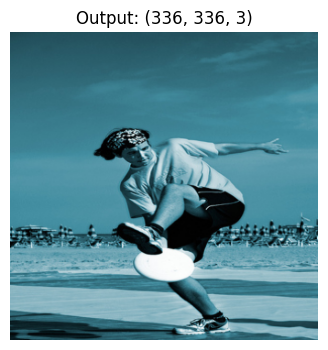

In [6]:
print("Consuming data with iter_torch_batches...")

# We select only the image column for the Tensor batch
image_ds = processed_ds.select_columns(["pixel_values"])

# iter_torch_batches automatically collates the Numpy arrays into Torch Tensors
for batch in image_ds.iter_torch_batches(batch_size=4):
    imgs = batch["pixel_values"]

    print(f"\nBatch Tensor Shape: {imgs.shape}")
    print(f"   Dtype: {imgs.dtype}")

    # Visualize the first image in the batch
    # This converts (C, H, W) tensor -> (H, W, C) numpy array automatically
    img_vis = kornia.utils.tensor_to_image(imgs[0])

    plt.figure(figsize=(4, 4))
    plt.imshow(img_vis)
    plt.title(f"Output: {img_vis.shape}")
    plt.axis("off")
    plt.show()

    break  # Only show one batch

## Batch Visualization with `make_grid`

When training VLMs, it's essential to **inspect entire batches** at a glance — not just one image at a time.

`kornia.image.make_grid` converts a `(B, C, H, W)` tensor into a single tiled image, perfect for debugging data pipelines.

2026-02-22 22:08:33,573	INFO logging.py:397 -- Registered dataset logger for dataset dataset_2_1


2026-02-22 22:08:33,573	INFO logging.py:405 -- dataset_2_1 registers for logging while another dataset dataset_2_0 is also logging. For performance reasons, we will not log to the dataset dataset_2_1 until it is the only active dataset.


2026-02-22 22:08:33,575	INFO streaming_executor.py:178 -- Starting execution of Dataset dataset_2_1. Full logs are in /tmp/ray/session_2026-02-22_22-06-51_176597_47128/logs/ray-data


2026-02-22 22:08:33,575	INFO streaming_executor.py:179 -- Execution plan of Dataset dataset_2_1: InputDataBuffer[Input] -> TaskPoolMapOperator[MapBatches(process_batch_rust)->Project]


2026-02-22 22:08:33,583	INFO progress_bar.py:213 -- === Ray Data Progress {MapBatches(process_batch_rust)->Project} ===


...

2026-02-22 22:08:33,585	INFO progress_bar.py:215 -- Running Dataset: dataset_2_1. Active & requested resources: 0/10 CPU, 0.0B/1.0GiB object store: Progress Completed 0 / ?


2026-02-22 22:08:38,640	INFO progress_bar.py:215 -- MapBatches(process_batch_rust)->Project: Tasks: 2 [backpressured:tasks]; Actors: 0; Queued blocks: 8 (0.0B); Resources: 2.0 CPU, 768.0MiB object store: Progress Completed 0 / ?


2026-02-22 22:08:38,642	INFO progress_bar.py:215 -- Running Dataset: dataset_2_1. Active & requested resources: 2/10 CPU, 768.0MiB/1.0GiB object store: Progress Completed 0 / ?


2026-02-22 22:08:43,693	INFO progress_bar.py:215 -- MapBatches(process_batch_rust)->Project: Tasks: 2; Actors: 0; Queued blocks: 0 (0.0B); Resources: 2.0 CPU, 2.6MiB object store: Progress Completed 8 / 16


2026-02-22 22:08:43,695	INFO progress_bar.py:215 -- Running Dataset: dataset_2_1. Active & requested resources: 2/10 CPU, 2.6MiB/1.0GiB object store: Progress Completed 8 / 16


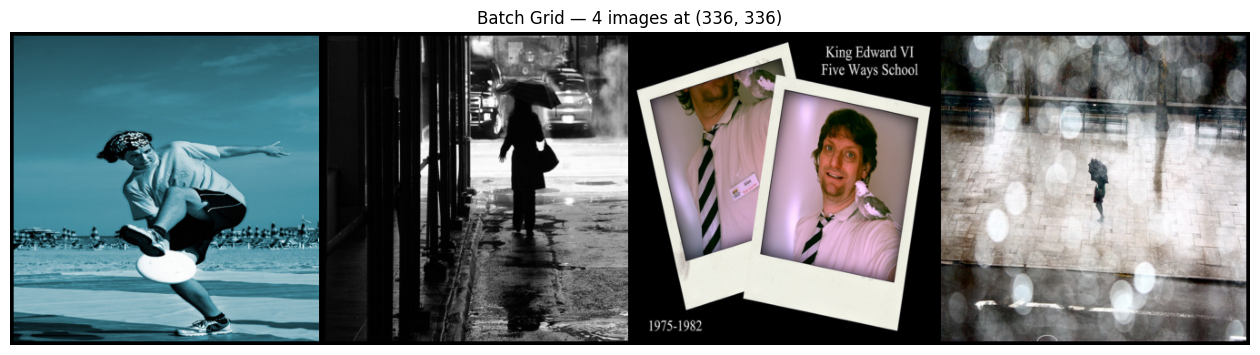

In [7]:
# Visualize a full batch as a grid (reuse the image-only dataset)
for batch in image_ds.iter_torch_batches(batch_size=BATCH_SIZE):
    batch_tensor = batch["pixel_values"]  # (B, 3, 336, 336)

    # make_grid expects float tensors in [0, 1]
    batch_float = batch_tensor.float() / 255.0

    # Create a grid: n_row controls how many images per row
    grid = make_grid(batch_float, nrow=BATCH_SIZE, padding=4)

    # Convert (C, H, W) grid tensor to numpy for matplotlib
    grid_np = kornia.utils.tensor_to_image(grid)

    plt.figure(figsize=(16, 5))
    plt.imshow(grid_np)
    plt.title(f"Batch Grid — {BATCH_SIZE} images at {TARGET_SIZE}")
    plt.axis("off")
    plt.show()

    break  # Show one batch

## Applying Kornia Augmentations

Kornia provides GPU-friendly, differentiable augmentations via `kornia.augmentation`.

`AugmentationSequential` lets you chain transforms in a pipeline — the same API works on single images and batches.

In [8]:
import kornia.augmentation as K

# Define an augmentation pipeline
aug_pipeline = K.AugmentationSequential(
    K.RandomHorizontalFlip(p=0.5),
    K.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=1.0),
    K.RandomGaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0), p=0.5),
    K.RandomRotation(degrees=15.0, p=0.5),
    data_keys=["input"],
)

print("Augmentation pipeline:")
print(aug_pipeline)

Augmentation pipeline:
AugmentationSequential(
  (RandomHorizontalFlip_0): RandomHorizontalFlip(p=0.5, p_batch=1.0, same_on_batch=False)
  (ColorJitter_1): ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=1.0, p_batch=1.0, same_on_batch=False)
  (RandomGaussianBlur_2): RandomGaussianBlur(sigma=(0.1, 2.0), p=0.5, p_batch=1.0, same_on_batch=False, kernel_size=(3, 3), separable=True, border_type=reflect)
  (RandomRotation_3): RandomRotation(degrees=15.0, p=0.5, p_batch=1.0, same_on_batch=False, resample=bilinear, align_corners=True)
)


### Before vs. After Augmentation

We apply the pipeline to the same batch and compare the original vs. augmented images side-by-side.

2026-02-22 22:08:48,123	INFO logging.py:397 -- Registered dataset logger for dataset dataset_2_2


2026-02-22 22:08:48,123	INFO logging.py:405 -- dataset_2_2 registers for logging while another dataset dataset_2_0 is also logging. For performance reasons, we will not log to the dataset dataset_2_2 until it is the only active dataset.


2026-02-22 22:08:48,124	INFO streaming_executor.py:178 -- Starting execution of Dataset dataset_2_2. Full logs are in /tmp/ray/session_2026-02-22_22-06-51_176597_47128/logs/ray-data


2026-02-22 22:08:48,124	INFO streaming_executor.py:179 -- Execution plan of Dataset dataset_2_2: InputDataBuffer[Input] -> TaskPoolMapOperator[MapBatches(process_batch_rust)->Project]


2026-02-22 22:08:48,132	INFO progress_bar.py:213 -- === Ray Data Progress {MapBatches(process_batch_rust)->Project} ===


...

2026-02-22 22:08:48,729	INFO progress_bar.py:215 -- Running Dataset: dataset_2_1. Active & requested resources: 1/10 CPU, 1.3MiB/1.0GiB object store: Progress Completed 12 / 16


2026-02-22 22:08:53,168	INFO progress_bar.py:215 -- MapBatches(process_batch_rust)->Project: Tasks: 2 [backpressured:tasks]; Actors: 0; Queued blocks: 8 (0.0B); Resources: 2.0 CPU, 768.0MiB object store: Progress Completed 0 / ?


2026-02-22 22:08:53,169	INFO progress_bar.py:215 -- Running Dataset: dataset_2_2. Active & requested resources: 2/10 CPU, 768.0MiB/1.0GiB object store: Progress Completed 0 / ?


2026-02-22 22:08:58,218	INFO progress_bar.py:215 -- MapBatches(process_batch_rust)->Project: Tasks: 2; Actors: 0; Queued blocks: 0 (0.0B); Resources: 2.0 CPU, 2.6MiB object store: Progress Completed 8 / 16


2026-02-22 22:08:58,220	INFO progress_bar.py:215 -- Running Dataset: dataset_2_2. Active & requested resources: 2/10 CPU, 2.6MiB/1.0GiB object store: Progress Completed 8 / 16


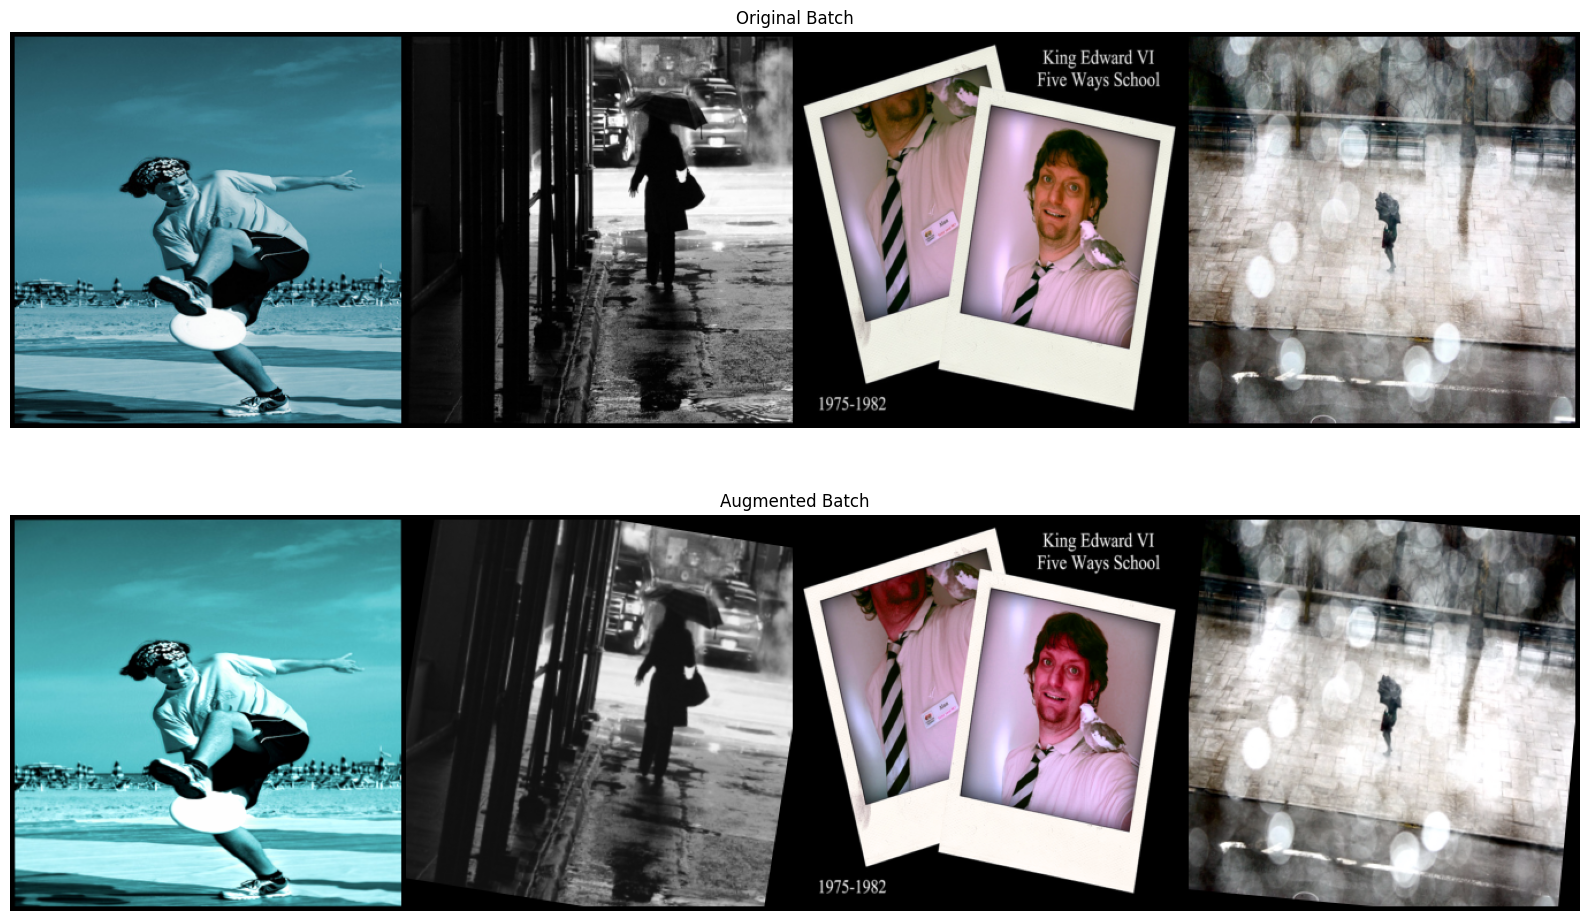

In [9]:
for batch in image_ds.iter_torch_batches(batch_size=BATCH_SIZE):
    batch_tensor = batch["pixel_values"]
    batch_float = batch_tensor.float() / 255.0

    # Apply augmentations
    augmented = aug_pipeline(batch_float)

    # Create grids for comparison
    grid_original = make_grid(batch_float, nrow=BATCH_SIZE, padding=4)
    grid_augmented = make_grid(augmented, nrow=BATCH_SIZE, padding=4)

    fig, axes = plt.subplots(2, 1, figsize=(16, 10))

    axes[0].imshow(kornia.utils.tensor_to_image(grid_original))
    axes[0].set_title("Original Batch")
    axes[0].axis("off")

    axes[1].imshow(kornia.utils.tensor_to_image(grid_augmented))
    axes[1].set_title("Augmented Batch")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    break  # Show one batch